# 01 – Exploratory Data Analysis (EDA)

### Purpose the Notebook
This notebook provides an Exploratory Data Analysis (EDA) of the TED Contract Award Notices (CAN) dataset.
This EDA combines structural inspection, descriptive statistics, visual exploration, and outlier detection to ensure that the dataset is consistent, interpretable, and ready for downstream analytical workflows.


### Steps
1. Data Structure & Completeness
- Load the full dataset using preprocessing utilities
- Inspect dataset dimensions (rows, columns)
- Review column types and identify fields requiring type correction
- Examine missing values and potential data quality issues

2. Exploratory Visualisations
- Analyse tender outcomes using a target distribution pie chart
- Visualise correlations between key numeric variables
- Identify the most represented countries in the dataset

3. Outlier Detection & Distribution Analysis
- Explore numeric variables using histograms and boxplots
- Apply IQR‑based outlier detection (1.5×IQR and 3×IQR)
- Apply MAD‑based outlier detection for financial variables
- Use log‑transform to reduce skewness in highly right‑skewed variables

---------------------

## Section 1 — Data Loading & Overview

--------------------------- 

--------------------
#### Imports & Setup & Dataset
-------------------

In [1]:
# ---------------------------------------------------------
# Import moduls
# ---------------------------------------------------------


# import standard modules
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
from pathlib import Path

In [2]:
# ---------------------------------------------------------
# Setup style
# ---------------------------------------------------------

# show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# visualisation settings
pd.set_option('display.float_format', '{:,.2f}'.format)

# seaborn style
sns.set_theme(style="whitegrid")

In [3]:
# ---------------------------------------------------------
# Load scripts
# ----------------------------------------------------------

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# found min directory
PROJECT_ROOT = Path("..").resolve()

# maindirectory sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# import function from script
from my_scripts.eda import (
    basic_preprocessing,
    filter_germany,
    load_years,
    overview
)

In [4]:
# ---------------------------------------------------------
# Import dataset
# ---------------------------------------------------------

# set setting
data_path = Path("..\\data")

# select all years
years = list(range(2008, 2017))   

# downloads for all years
df = load_years(data_path, years)

df = basic_preprocessing(df)

In [5]:
# Germany dataset
df_de = filter_germany(df)

-----------------
### Basic structure

---------------

In [6]:
print("Shape EU-dataset:", df.shape)
print("Shape Germany-dataset:", df_de.shape)

Shape EU-dataset: (4362869, 75)
Shape Germany-dataset: (309652, 75)


In [8]:
df.head()

,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,NUMBER_AWARDS,ID_AWARD,ID_LOT_AWARDED,INFO_ON_NON_AWARD,INFO_UNPUBLISHED,B_AWARDED_TO_A_GROUP,WIN_NAME,WIN_NATIONALID,WIN_ADDRESS,WIN_TOWN,WIN_POSTAL_CODE,WIN_COUNTRY_CODE,B_CONTRACTOR_SME,CONTRACT_NUMBER,TITLE,NUMBER_OFFERS,NUMBER_TENDERS_SME,NUMBER_TENDERS_OTHER_EU,NUMBER_TENDERS_NON_EU,NUMBER_OFFERS_ELECTR,AWARD_EST_VALUE_EURO,AWARD_VALUE_EURO,AWARD_VALUE_EURO_FIN_1,B_SUBCONTRACTED,DT_AWARD
0,200880,ted.europa.eu/udl?uri=TED:NOTICE:80-2008:TEXT:...,2008,3,11-DEC-07,D205,0,0,NaN,St. Elisabeth-Krankenhaus Leipzig,NaN,Biedermannstraße 84,Leipzig,04277,NaN,DE,NaN,NaN,NaN,8,NaN,Health;Social protection,NaN,NaN,NaN,W,DED31,N,NaN,N,NaN,"45,215,000.00",NaN,NaN,45000000,N,NaN,0.00,NaN,"302,964.15","302,964.15",NaN,OPE,NaN,0,M,NaN,Preis---Qualität,60---40,N,1,"2,157,402.00",NaN,NaN,N,NaN,Caverion GmbH Gebäudetechnik,NaN,Walter-Köhn-Straße 1c,Leipzig,04356,DE,NaN,265-02-028,NaN,2.00,NaN,NaN,NaN,NaN,NaN,"302,964.15","302,964.15",NaN,29-SEP-07
1,200881,ted.europa.eu/udl?uri=TED:NOTICE:81-2008:TEXT:...,2008,3,27-DEC-07,D205,0,0,NaN,Stadt Wolfsburg,NaN,Porschestr. 49,Wolfsburg,38440,NaN,DE,NaN,NaN,NaN,3,NaN,General public\services,N,NaN,NaN,W,DE913,N,NaN,N,NaN,"45,215,100.00",NaN,NaN,45110000---45223220---45231300---45261420---45...,Y,NaN,0.00,NaN,"478,780.08","478,780.08",N,OPE,NaN,0,L,100.00,NaN,NaN,N,1,"2,157,403.00",NaN,NaN,N,NaN,Reitmeier Bau und Wohnungsbau GmbH,NaN,Leinering 21,Wolfsburg,38446,DE,NaN,07-0204 / 07-0274,NaN,3.00,NaN,NaN,NaN,NaN,NaN,"478,780.08","478,780.08",N,21-DEC-07
2,200882,ted.europa.eu/udl?uri=TED:NOTICE:82-2008:TEXT:...,2008,3,27-DEC-07,D205,0,0,NaN,Ville de Pau,NaN,Hôtel de Ville - place Royale,Pau,64036,NaN,FR,NaN,NaN,NaN,3,NaN,NaN,N,NaN,NaN,W,NaN,Y,NaN,Y,NaN,"45,421,145.00",NaN,NaN,NaN,Y,NaN,0.00,NaN,NaN,NaN,N,OPE,NaN,0,M,NaN,Prix---Délai d'intervention d'urgence,80---20,N,1,"2,157,404.00",NaN,NaN,N,NaN,Société TEXIA,NaN,15; rue Richelieu,Pau,64000,FR,NaN,2007-136,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,20-NOV-07
3,200883,ted.europa.eu/udl?uri=TED:NOTICE:83-2008:TEXT:...,2008,3,27-DEC-07,D205,0,0,NaN,Opac de Saint-Quentin,NaN,142; boulevard Gambetta; B.P. 41,Saint-Quentin,02101,NaN,FR,NaN,NaN,NaN,6,NaN,Housing and community amenities,N,NaN,NaN,W,NaN,N,NaN,N,NaN,"45,211,100.00",NaN,NaN,NaN,Y,NaN,0.00,NaN,"2,255,999.00","2,255,999.00",NaN,NIC,NaN,0,M,NaN,prix des prestations---valeur technique de l'o...,55---45,NaN,1,"2,157,405.00",NaN,NaN,N,NaN,S.A.C ( Société anizienne de construction),NaN,NaN,Anizy- le-Château,02320,FR,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,255,999.00","2,255,999.00",NaN,07-DEC-07
4,200884,ted.europa.eu/udl?uri=TED:NOTICE:84-2008:TEXT:...,2008,3,27-DEC-07,D205,0,0,NaN,Ministerio de Fomento; Secretaria de Estado de...,NaN,Plaza de los Sagrados Corazones; 7,Madrid,28071,NaN,ES,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,W,NaN,N,NaN,N,NaN,"45,234,116.00",NaN,NaN,NaN,NaN,NaN,0.00,NaN,"23,462,327.59","23,462,327.59",NaN,OPE,NaN,0,M,NaN,Oferta Técnica---Oferta económica,70---30,NaN,1,"2,157,406.00",NaN,NaN,N,NaN,Sociedad Anonima de Obras y Servicios; Copasa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"30,657,786.21","23,462,327.59","23,462,327.59",NaN,14-DEC-07


In [7]:
df.columns

Index(['ID_NOTICE_CAN', 'TED_NOTICE_URL', 'YEAR', 'ID_TYPE', 'DT_DISPATCH',
       'XSD_VERSION', 'CANCELLED', 'CORRECTIONS', 'B_MULTIPLE_CAE', 'CAE_NAME',
       'CAE_NATIONALID', 'CAE_ADDRESS', 'CAE_TOWN', 'CAE_POSTAL_CODE',
       'CAE_GPA_ANNEX', 'ISO_COUNTRY_CODE', 'ISO_COUNTRY_CODE_GPA',
       'B_MULTIPLE_COUNTRY', 'ISO_COUNTRY_CODE_ALL', 'CAE_TYPE',
       'EU_INST_CODE', 'MAIN_ACTIVITY', 'B_ON_BEHALF',
       'B_INVOLVES_JOINT_PROCUREMENT', 'B_AWARDED_BY_CENTRAL_BODY',
       'TYPE_OF_CONTRACT', 'TAL_LOCATION_NUTS', 'B_FRA_AGREEMENT',
       'FRA_ESTIMATED', 'B_FRA_CONTRACT', 'B_DYN_PURCH_SYST', 'CPV',
       'MAIN_CPV_CODE_GPA', 'ID_LOT', 'ADDITIONAL_CPVS', 'B_GPA',
       'GPA_COVERAGE', 'LOTS_NUMBER', 'VALUE_EURO', 'VALUE_EURO_FIN_1',
       'VALUE_EURO_FIN_2', 'B_EU_FUNDS', 'TOP_TYPE', 'B_ACCELERATED',
       'OUT_OF_DIRECTIVES', 'CRIT_CODE', 'CRIT_PRICE_WEIGHT', 'CRIT_CRITERIA',
       'CRIT_WEIGHTS', 'B_ELECTRONIC_AUCTION', 'NUMBER_AWARDS', 'ID_AWARD',
       'ID_LOT_AWA

#### Notes: Basic structure
The dataset contains 4,362,869 rows and 75 columns.
A detailed description of all column meanings, formats, and data definitions is provided in the Data_dictionary file located in the data/ folder.

--------------------

### Data quality

-----------------

In [9]:
# ---------------------------------------------------------
# EU
# ----------------------------------------------------------

overview(df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
ID_NOTICE_CAN,int64,4362869,0,0.00,1404322,"[200880, 200881, 200882, 200883, 200884, 20088..."
TED_NOTICE_URL,str,4362869,0,0.00,1404322,[ted.europa.eu/udl?uri=TED:NOTICE:80-2008:TEXT...
YEAR,int64,4362869,0,0.00,9,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 201..."
ID_TYPE,int64,4362869,0,0.00,7,"[3, 6, 18, 25, 21, 23, 22]"
DT_DISPATCH,str,4362869,0,0.00,3297,"[11-DEC-07, 27-DEC-07, 28-DEC-07, 19-DEC-07, 2..."
XSD_VERSION,str,4362869,0,0.00,7,"[D205, D206, D207, R207.S3, R208.S1, R208.S2, ..."
CANCELLED,int64,4362869,0,0.00,2,"[0, 1]"
CORRECTIONS,int64,4362869,0,0.00,10,"[0, 1, 2, 4, 3, 5, 84, 7, 8, 6]"
B_MULTIPLE_CAE,object,148895,4213974,96.59,2,"[nan, N, Y]"
CAE_NAME,str,4362867,2,0.00,196676,"[St. Elisabeth-Krankenhaus Leipzig, Stadt Wolf..."


In [10]:
# ---------------------------------------------------------
# Germany
# ----------------------------------------------------------

overview(df_de)

,dtype,total,missing_n,missing_%,uniques_n,uniques
ID_NOTICE_CAN,int64,309652,0,0.00,183731,"[200880, 200881, 200890, 2008111, 2008112, 200..."
TED_NOTICE_URL,str,309652,0,0.00,183731,[ted.europa.eu/udl?uri=TED:NOTICE:80-2008:TEXT...
YEAR,int64,309652,0,0.00,9,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 201..."
ID_TYPE,int64,309652,0,0.00,5,"[3, 6, 18, 25, 21]"
DT_DISPATCH,str,309652,0,0.00,2805,"[11-DEC-07, 27-DEC-07, 19-DEC-07, 28-DEC-07, 2..."
XSD_VERSION,str,309652,0,0.00,7,"[D205, D206, D207, R207.S3, R208.S1, R208.S2, ..."
CANCELLED,int64,309652,0,0.00,2,"[0, 1]"
CORRECTIONS,int64,309652,0,0.00,3,"[0, 1, 2]"
B_MULTIPLE_CAE,object,16255,293397,94.75,2,"[nan, N, Y]"
CAE_NAME,str,309652,0,0.00,27322,"[St. Elisabeth-Krankenhaus Leipzig, Stadt Wolf..."


#### Notes: Data Quality Overview

1. Columns with excessive missing data (recommended for removal)
Several variables contain extremely high proportions of missing values (often >90–95%), making them unsuitable for analysis or modeling. These include:
- WIN_NAME, WIN_ADDRESS, WIN_TOWN, WIN_POSTAL_CODE — award‑stage winner information is missing for the majority of records.
- CRIT_PRICE_WEIGHT, CRIT_QUALITY_WEIGHT — evaluation criteria weights are sparsely populated and inconsistent across years.
- AWARD_VALUE_EURO_FIN_1 — secondary award value field with large gaps and duplication of the main award value.
- B_SUBCONTRACTED — subcontracting indicator is missing for more than half of observations.
- ADDITIONAL_CPVS — supplementary CPV codes appear only in a small subset of tenders.
- GPA_COVERAGE, B_GPA — GPA‑related fields are mostly empty and not consistently reported.
- These variables provide limited analytical value and can be safely excluded from the core dataset.

2. Columns requiring type corrections
Several fields are stored as object but represent structured or numeric information:
- DT_AWARD, DT_DISPATCH, DT_RECEIPT
  - Currently stored as strings.
  - Should be converted to datetime for temporal analysis and modeling.
- VALUE_EURO, AWARD_VALUE_EURO, AWARD_EST_VALUE_EURO
  - Numeric fields with missing values and occasional formatting inconsistencies.
  - Convert to float, ensure coercion of invalid entries, and consider log‑transformation for modeling.
- ISO_COUNTRY_CODE, TYPE_OF_CONTRACT, MAIN_CPV_CODE_GPA
  - Categorical fields stored as object.
  - Convert to category to reduce memory usage and improve model performance.
- NUMBER_OFFERS
  - Should be numeric (int), but contains non‑numeric placeholders.
  - Convert using pd.to_numeric(errors="coerce").

3. Columns with high cardinality (handle with care)
Some variables contain extremely large numbers of unique values:
- TED_NOTICE_URL — unique per tender; not useful for modeling.
- CAE_ADDRESS, CAE_TOWN, CAE_NAME — contracting authority identifiers; high cardinality and inconsistent formatting.
- WIN_NAME, WIN_ADDRESS — winner identifiers; high cardinality and sparse.
These fields are not suitable for direct modeling and should be excluded or replaced with aggregated features (e.g., country‑level or CPV‑level indicators).

4. Columns with consistent and reliable structure (recommended to keep)
These variables are well‑populated and analytically meaningful:
- YEAR — newly added; essential for trend analysis.
- ISO_COUNTRY_CODE — complete and consistent.
- TYPE_OF_CONTRACT — stable categorical variable.
- MAIN_CPV_CODE_GPA — core classification of procurement subject.
- NUMBER_OFFERS — key variable for competition analysis.
- VALUE_EURO / AWARD_VALUE_EURO — central economic indicators.
- CRIT_PRICE_WEIGHT, CRIT_CRITERIA, CRIT_WEIGHTS - a high proportion of missing values ​​(​​over 50%), yet it may be important for NLP.
These should form the backbone of your analytical dataset.

5. Additional recommended preprocessing steps
- Remove exact duplicate rows (your dataset contains >2.5M duplicates).
- Normalize CPV codes (strip whitespace, ensure consistent formatting).
- Standardize country codes (ISO 2‑letter format is already good).
- Create derived features such as:
  - IS_FAILED_TENDER (0–1 offers)
  - IS_LOW_COMPETITION (2 offers)
  - LOG_VALUE_EURO
  - CPV_SECTION (first 2 digits of CPV)
These will significantly improve interpretability and model performance.

-----------------
### Descriptive statistics
---------------

In [12]:
# ---------------------------------------------------------
# EU
# ----------------------------------------------------------

df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID_NOTICE_CAN,"4,362,869.00","1,512,230,040.81","818,517,533.27","20,155.00","201,622,617.00","2,011,239,877.00","2,014,229,433.00","2,016,466,898.00"
YEAR,"4,362,869.00","2,012.32",2.52,"2,008.00","2,010.00","2,012.00","2,015.00","2,016.00"
ID_TYPE,"4,362,869.00",3.25,1.14,3.00,3.00,3.00,3.00,25.00
CANCELLED,"4,362,869.00",0.00,0.03,0.00,0.00,0.00,0.00,1.00
CORRECTIONS,"4,362,869.00",0.01,0.13,0.00,0.00,0.00,0.00,84.00
CPV,"4,357,860.00","47,412,065.50","21,585,283.86","1,000,000.00","33,162,100.00","39,160,000.00","66,510,000.00","99,100,000.00"
MAIN_CPV_CODE_GPA,"1,639,715.00",109.88,203.69,0.00,33.00,39.00,71.00,806.00
GPA_COVERAGE,"1,639,715.00",1.94,1.34,1.00,1.00,1.00,3.00,5.00
LOTS_NUMBER,"4,350,004.00",21.66,76.01,0.00,0.00,1.00,11.00,"1,137.00"
VALUE_EURO,"2,624,436.00","524,784,487,241,368,862,720.00","831,779,254,825,732,232,183,808.00",0.00,"203,058.14","535,109.90","1,799,187.00","1,347,157,649,092,480,597,193,916,416.00"


In [13]:
# ---------------------------------------------------------
# Germany
# ----------------------------------------------------------

df_de.describe().T

,count,mean,std,min,25%,50%,75%,max
ID_NOTICE_CAN,"309,652.00","1,628,299,079.33","747,366,276.85","200,880.00","2,008,297,555.75","2,012,184,967.50","2,014,415,801.00","2,016,466,867.00"
YEAR,"309,652.00","2,012.58",2.53,"2,008.00","2,010.00","2,013.00","2,015.00","2,016.00"
ID_TYPE,"309,652.00",3.34,1.66,3.00,3.00,3.00,3.00,25.00
CANCELLED,"309,652.00",0.00,0.02,0.00,0.00,0.00,0.00,1.00
CORRECTIONS,"309,652.00",0.01,0.10,0.00,0.00,0.00,0.00,2.00
CPV,"308,025.00","50,402,836.30","21,030,025.59","1,000,000.00","34,144,210.00","45,220,000.00","71,000,000.00","99,100,000.00"
MAIN_CPV_CODE_GPA,"129,670.00",112.89,197.39,3.00,34.00,45.00,72.00,806.00
GPA_COVERAGE,"129,670.00",1.90,1.30,1.00,1.00,1.00,3.00,5.00
LOTS_NUMBER,"308,885.00",9.82,30.58,0.00,0.00,0.00,4.00,275.00
VALUE_EURO,"153,965.00","194,849,478,778,049,069,056.00","76,455,767,364,727,482,613,760.00",0.01,"196,445.34","418,196.64","1,203,935.29","30,000,000,000,000,004,865,392,640.00"


#### Notes: Descriptype analyse of Numerical Data
1. General structure of numeric variables
Most numeric fields have very large counts (3–4 million), confirming that the dataset is broadly complete for core procurement indicators.
Several variables show substantial variance and heavy right‑skew (e.g., award values, estimated values), which is typical for procurement datasets where a small number of tenders have extremely high contract values.

2. Variables with strong completeness (recommended to keep)
These fields have high counts and stable distributions:
- YEAR — fully populated; essential for trend analysis.
- ID_NOTICE_CAN, ID_AWARD, ID_TYPE — identifiers with complete coverage.
- NUMBER_OFFERS — key competition indicator; distribution shows realistic variation (min=0, max>100).
- VALUE_EURO, AWARD_VALUE_EURO, AWARD_EST_VALUE_EURO — central economic variables with high coverage.
- LOTS_NUMBER — well‑populated; useful for structural analysis of tenders.
- NUMBER_AWARDS — consistent and complete.
These variables form the backbone of quantitative analysis.

3. Variables with partial completeness (use with caution)
Some fields have moderate missingness or inconsistent reporting:
- NUMBER_TENDERS_SME
- NUMBER_TENDERS_OTHER_EU
- NUMBER_TENDERS_NON_EU
- NUMBER_OFFERS_ELECTR
These variables are often sparsely populated across countries and years.
They may be retained for descriptive analysis but are not reliable for modeling.

4. Variables with extremely high missingness (recommended for removal)
The following numeric fields show very low counts relative to the dataset size:
- VALUE_EURO_FIN_1
- VALUE_EURO_FIN_2
- AWARD_VALUE_EURO_FIN_1
These appear to be alternative or secondary financial fields, often duplicating the main award value or containing incomplete reporting.
Given their low coverage and redundancy, they can be safely dropped.

5. Distributional observations
- Contract values (VALUE_EURO, AWARD_VALUE_EURO)
  - Highly skewed with very large maximum values (tens or hundreds of millions).
  - Log‑transformation is recommended for modeling.
- NUMBER_OFFERS
  - Median around 3–4 offers, but minimum is 0 and maximum exceeds 100.
  - This confirms the presence of both failed tenders (0–1 offers) and highly competitive ones.
- LOTS_NUMBER
  - Median is 1, but maximum is very high, indicating multi‑lot mega‑projects.
  - Consider capping or binning for modeling.

6. Recommended preprocessing steps based on describe()
Convert financial fields to float and handle outliers (log-transform or winsorize).
Convert date fields to datetime (DT_AWARD, DT_DISPATCH, DT_RECEIPT).
Remove secondary financial fields with low coverage.
Check for unrealistic values (e.g., negative amounts, extremely large numbers).
Create derived features:
- IS_FAILED_TENDER (0–1 offers)
- IS_LOW_COMPETITION (2 offers)
- LOG_AWARD_VALUE
- CPV_SECTION (first 2 digits of CPV)

---------------------
### Dublicats

---------------

In [14]:
# exact duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
# repeat tenders by year
df.drop(columns=["YEAR"]).duplicated().sum()

np.int64(0)

#### Notes: Duplicate Check Summary
The dataset contains no full duplicates, even when the YEAR column is excluded from comparison.
Additionally, there are no repeated tenders with identical characteristics across different years, indicating that each procurement record represents a unique publication without cross‑year duplication.

--------------------

### Target analyse

-----------------------

In [16]:
# ---------------------------------------------------------
# EU
# ---------------------------------------------------------

total = len(df)

failed = df[df["NUMBER_OFFERS"].fillna(0) <= 1]
risk = df[df["NUMBER_OFFERS"] == 2]

print("European Union:")
print("Total number of tenders in EU:", len(df))
print("Failed tenders (0–1 participant)):", len(failed))
print("Share (in %) of the total:", round(len(failed) / total * 100, 2), "%")

print("High-risk tenders (2 participants):", len(risk))
print("Share (in %) of the total:", round(len(risk) / total * 100, 2), "%")

European Union:
Total number of tenders in EU: 4362869
Failed tenders (0–1 participant)): 1676668
Share (in %) of the total: 38.43 %
High-risk tenders (2 participants): 576874
Share (in %) of the total: 13.22 %


In [17]:
# ---------------------------------------------------------
# Germany
# ---------------------------------------------------------

# Competition check

total = len(df_de)

failed = df_de[df_de["NUMBER_OFFERS"].fillna(0) <= 1]
risk = df_de[df_de["NUMBER_OFFERS"] == 2]

print("Germany:")
print("Number of tenders in Germany:", len(df_de))
print("Failed tenders (0–1 participant)):", len(failed))
print("Share (in %) of the total:", round(len(failed) / total * 100, 2), "%")

print("High-risk tenders (2 participants):", len(risk))
print("Share (in %) of the total:", round(len(risk) / total * 100, 2), "%")

Germany:
Number of tenders in Germany: 309652
Failed tenders (0–1 participant)): 84747
Share (in %) of the total: 27.37 %
High-risk tenders (2 participants): 33235
Share (in %) of the total: 10.73 %


In [18]:
# ---------------------------------------------------------
# Target visualisation
# ---------------------------------------------------------

# import function from script
from my_scripts.visualization import (plot_target_distribution, visual_de)


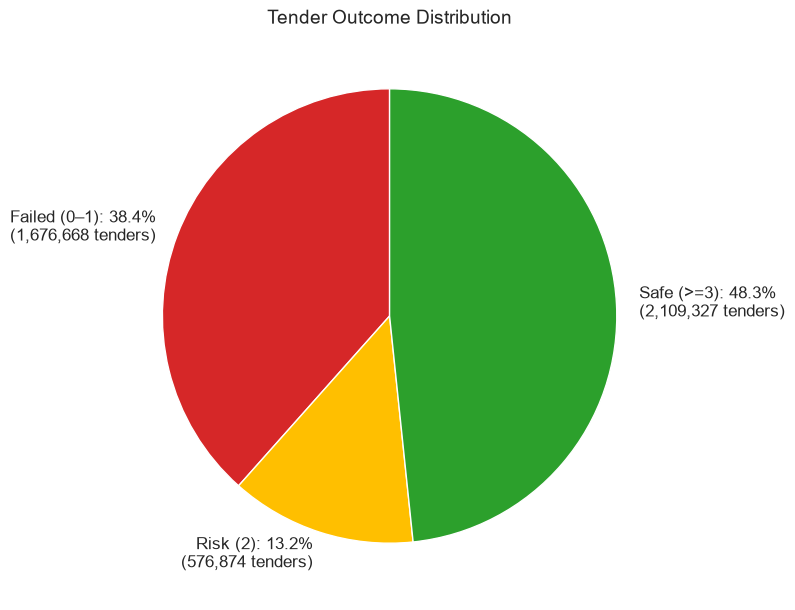

In [19]:
# target distribution - EU
plot_target_distribution(df, save=True)


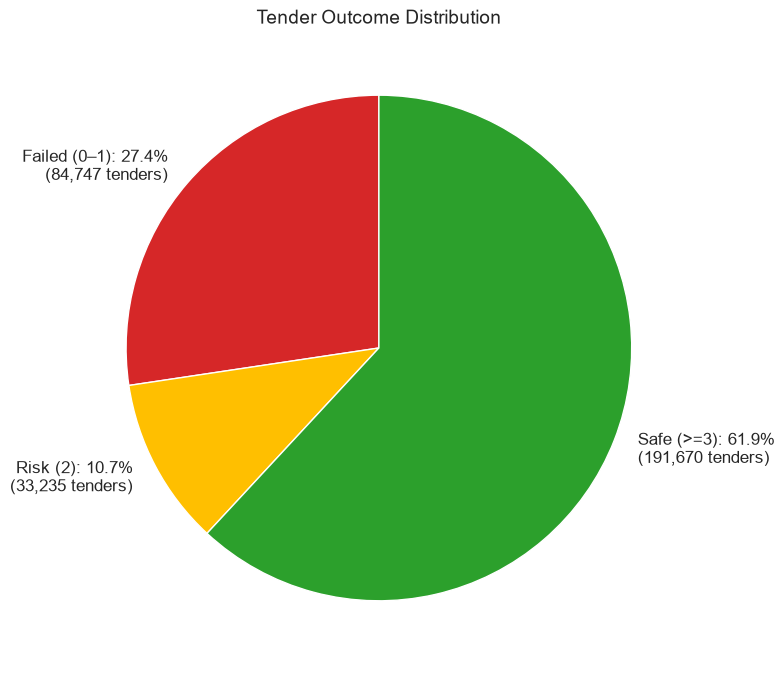

In [20]:
# target distribution - DE
plot_target_distribution(df_de, save=True, path = visual_de)


#### Notes:  Target Patterns

1. Overall EU

The full dataset contains 4.36 million procurement records, providing a broad and diverse basis for statistical analysis and model training.
The share of failed tenders (0–1 participant) is 38.43%, indicating a substantial portion of procedures with insufficient competition.
High‑risk tenders (2 participants) represent 13.22% of all records, suggesting that limited competition is a recurring structural pattern across the EU market.
These proportions highlight consistent cross‑country patterns of low bidder participation, which can be leveraged for robust modeling and comparative analysis.

2. Germany‑Specific Patterns

Germany accounts for 309,652 records, a sufficiently large subset for targeted descriptive analysis but comparatively smaller for standalone predictive modeling.
The share of failed tenders in Germany is 27.37%, notably lower than the EU average, indicating relatively stronger competitive dynamics.
High‑risk tenders represent 10.73%, also below the EU benchmark, suggesting a more stable procurement environment with fewer structurally risky procedures.
The deviation of German indicators from EU‑wide averages implies country‑specific procurement behavior that merits separate examination.

------------------------------
## Section 2 — Visual Exploration

-----------------------------

In [21]:
# import function from script
from my_scripts.visualization import (plot_correlation_matrix, plot_bar_top_categories)

# selection of numeric columns
numeric_cols = ["VALUE_EURO", "AWARD_VALUE_EURO", "NUMBER_OFFERS", "LOTS_NUMBER"]



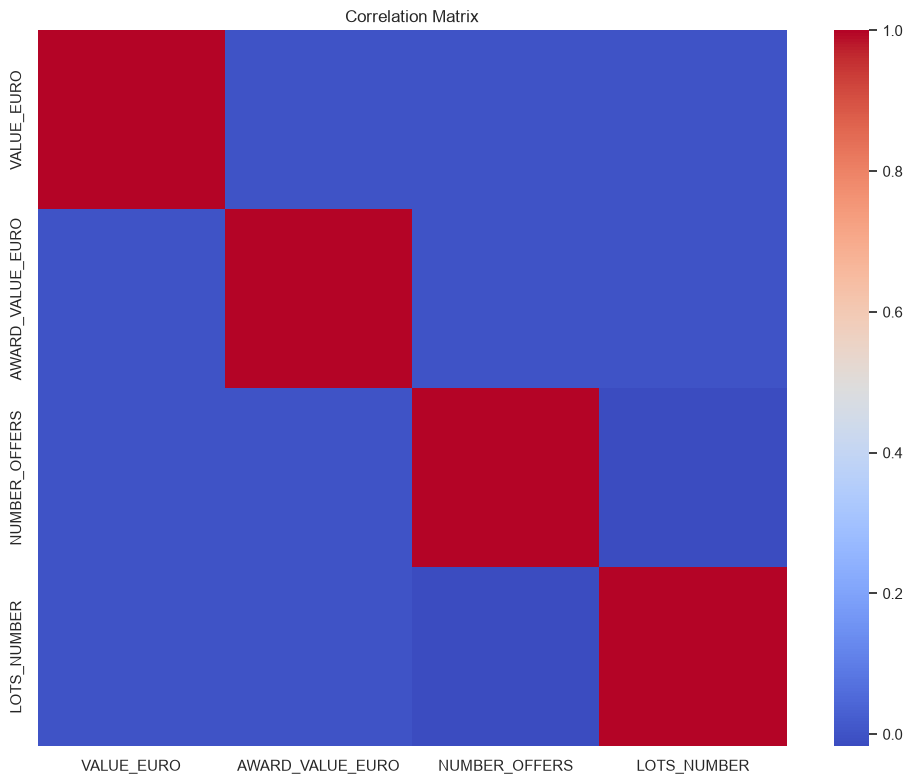

In [22]:
# ---------------------------------------------------------
# Correlations matrix
# ---------------------------------------------------------

plot_correlation_matrix(df, numeric_cols, save=True)



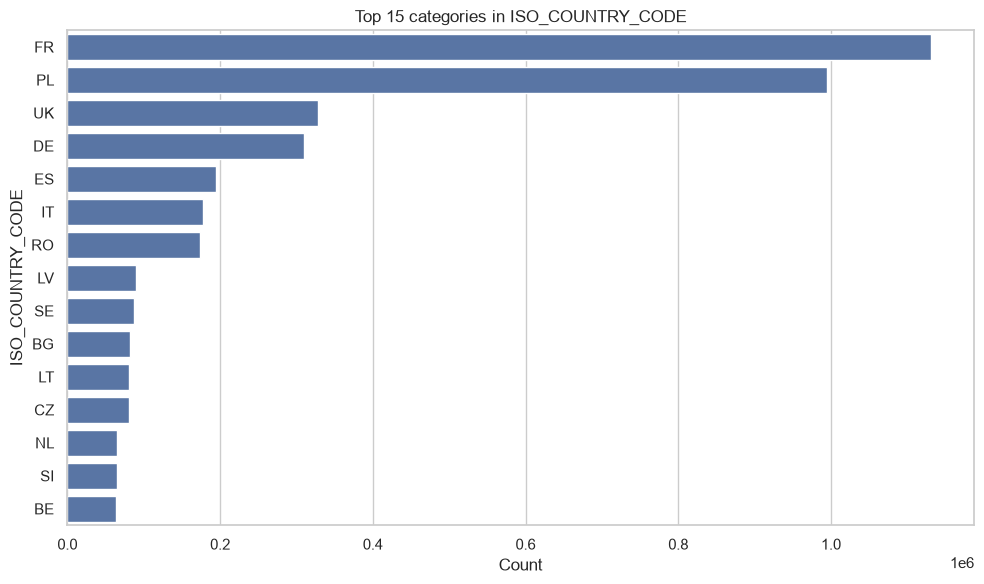

In [23]:
# ---------------------------------------------------------
# top countries
# ---------------------------------------------------------

plot_bar_top_categories(df, "ISO_COUNTRY_CODE", top_n=15, save=True)

#### Notes: Visualisations Insights

1. Correlation Matrix:
The numeric variables show very weak correlations with each other. VALUE_EURO and AWARD_VALUE_EURO do not meaningfully correlate with NUMBER_OFFERS or LOTS_NUMBER. This suggests that tender value, number of offers, and number of lots behave independently and require separate analytical treatment.

2. Top 15 categories in ISO_COUNTRY_CODE:
The distribution of contract notices is highly uneven across countries. France and Poland dominate the dataset, followed by the UK and Germany. Smaller EU member states appear far less frequently, which may reflect differences in procurement volume or reporting intensity.

-------------------------
### Section 3 — Outlier Analysis

----------------

In [24]:
# import function from script
from my_scripts.outliers import (log_transform, iqr_outliers, mad_outliers,
                                 plot_hist, plot_box, visual_de)

In [25]:
# selection of numeric columns
numeric_cols = ["VALUE_EURO", "AWARD_VALUE_EURO", "NUMBER_OFFERS", "LOTS_NUMBER"]
df_num = df[numeric_cols].copy()

In [ ]:
# ---------------------------------------------------------
# Visualize distributions
# ---------------------------------------------------------

=== VALUE_EURO ===


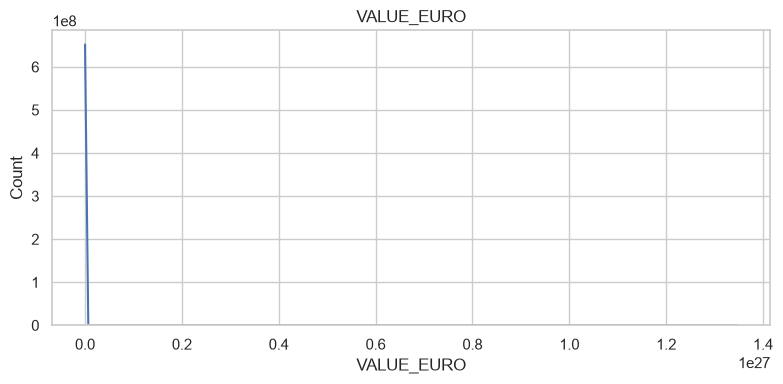

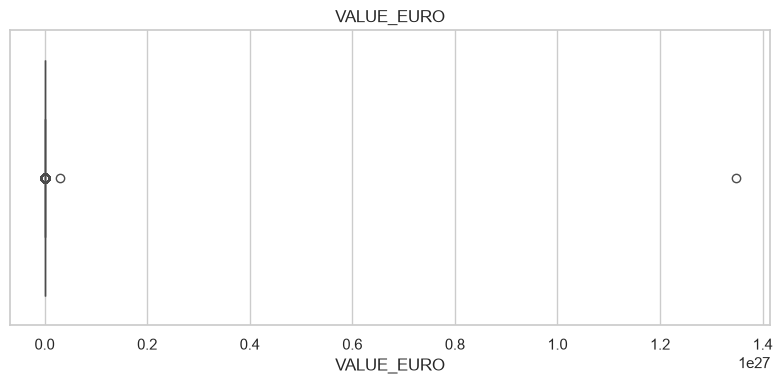

=== AWARD_VALUE_EURO ===


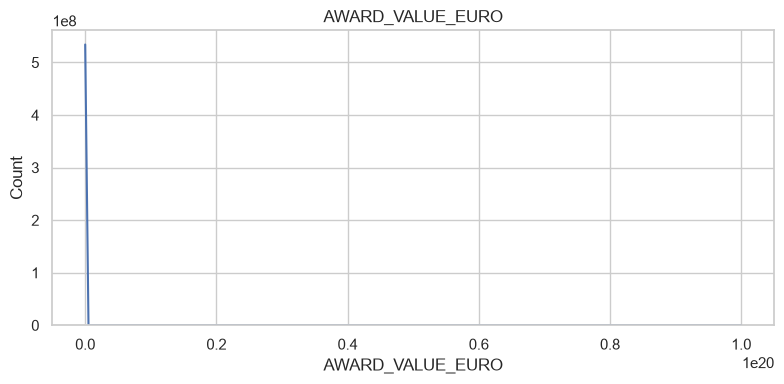

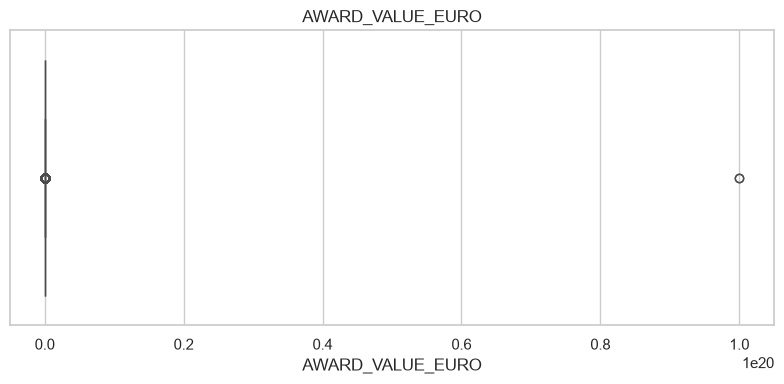

=== NUMBER_OFFERS ===


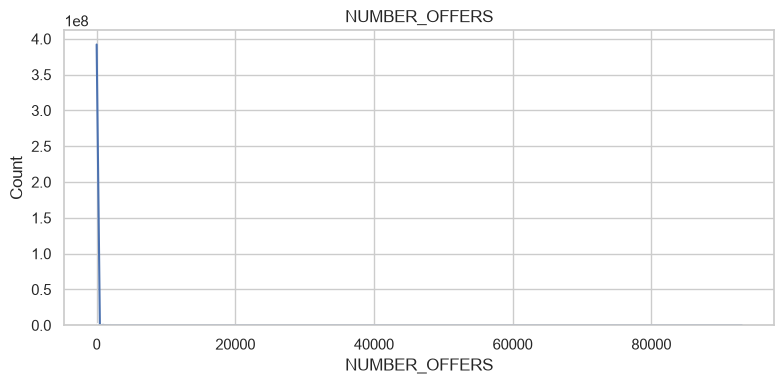

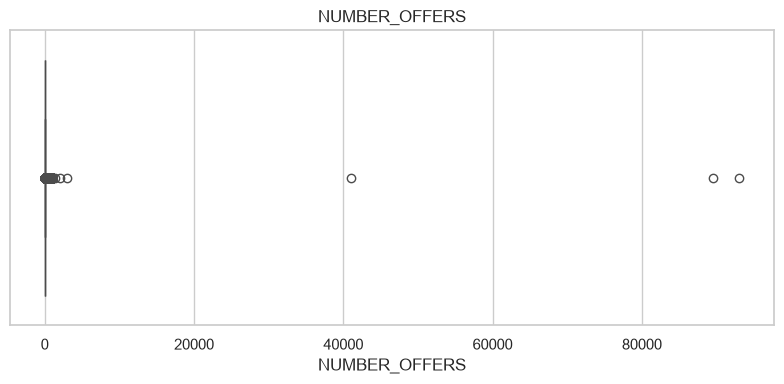

=== LOTS_NUMBER ===


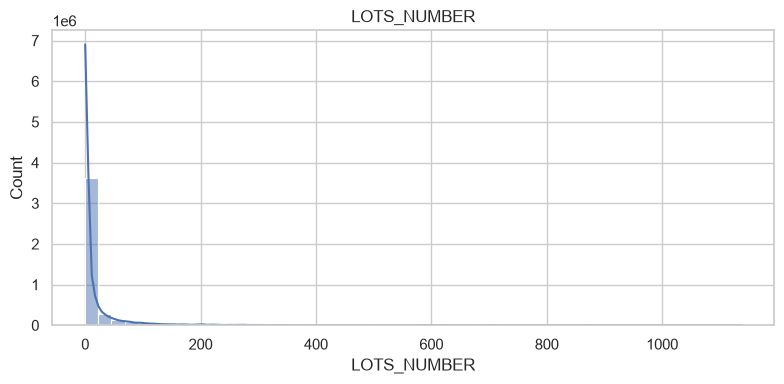

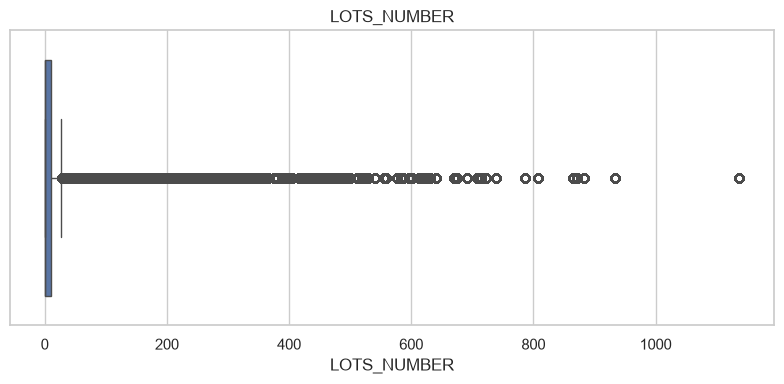

In [26]:
# ---------------------------------------------------------
# EU
# ---------------------------------------------------------

for col in numeric_cols:
    print(f"=== {col} ===")
    
    # Histogram
    plot_hist(df_num[col], f"{col}", save=True)
    
    # Boxplot
    plot_box(df_num[col], f"{col}", save=True)


=== VALUE_EURO ===


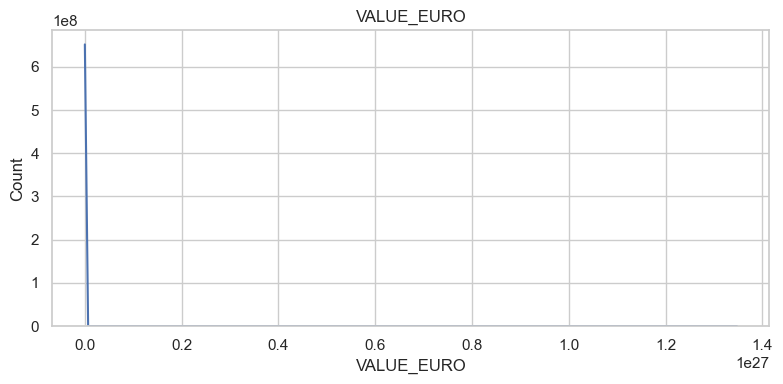

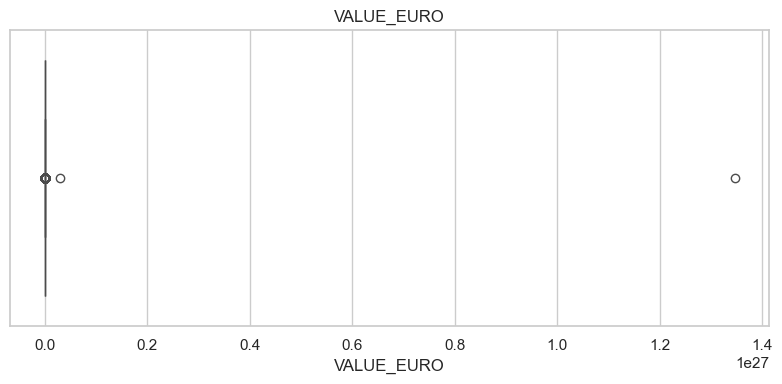

=== AWARD_VALUE_EURO ===


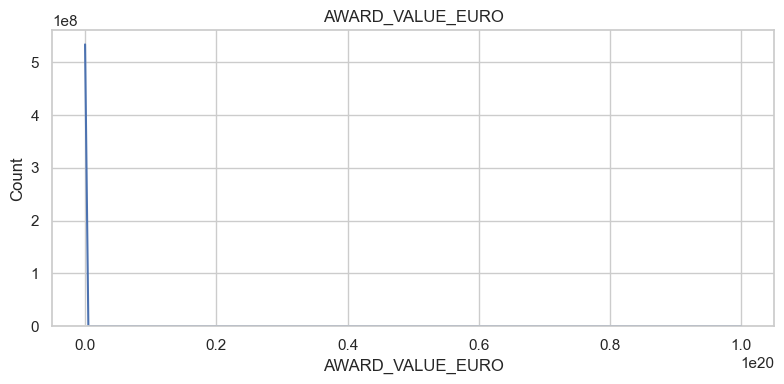

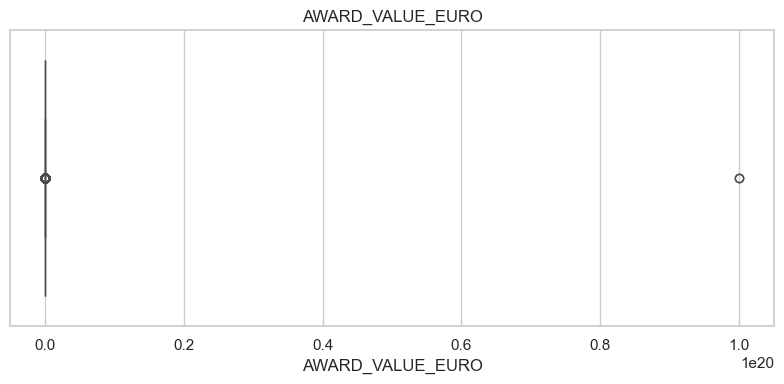

=== NUMBER_OFFERS ===


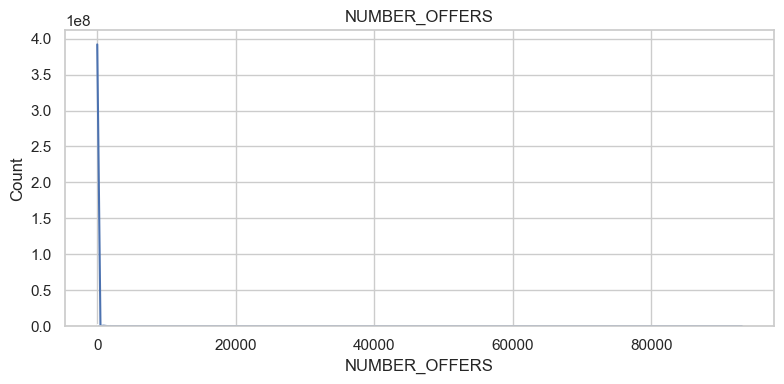

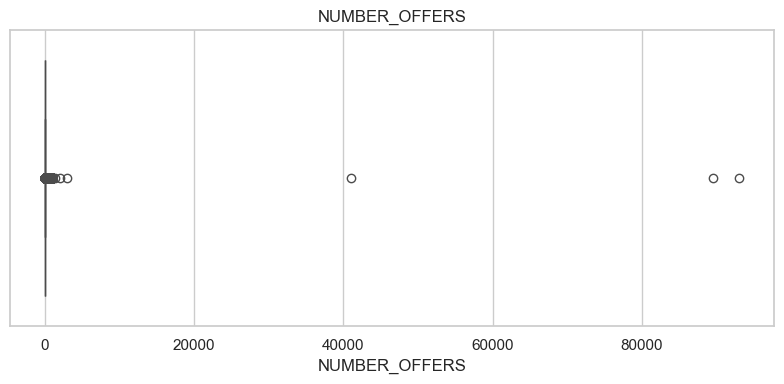

=== LOTS_NUMBER ===


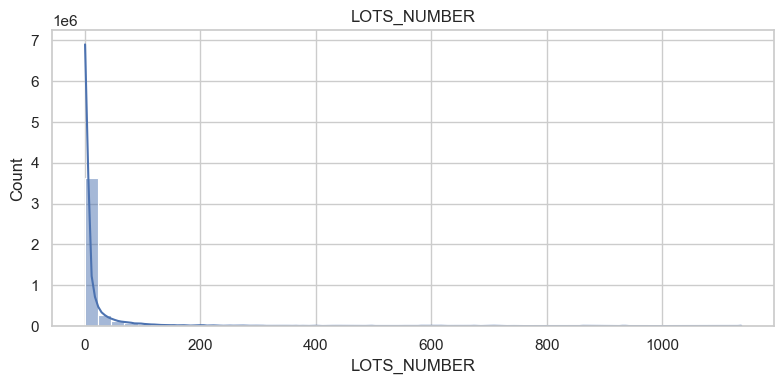

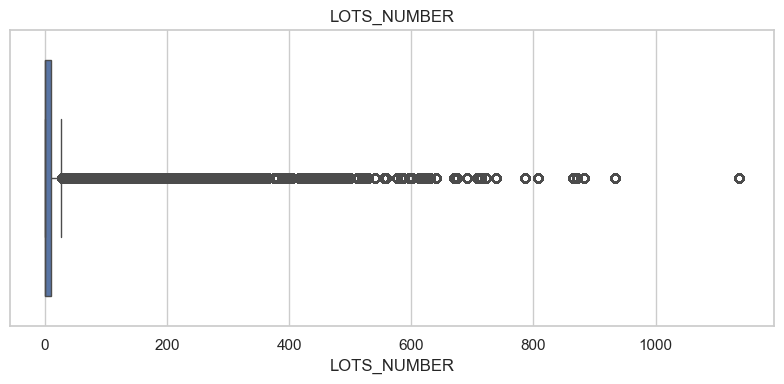

In [87]:
# ---------------------------------------------------------
# Germany
# ---------------------------------------------------------

for col in numeric_cols:
    print(f"=== {col} ===")
    
    # Histogram
    plot_hist(df_num[col], f"{col}", save=True, path = visual_de)
    
    # Boxplot
    plot_box(df_num[col], f"{col}", save=True, path = visual_de)

In [27]:
# removal of an unrealistic number of proposals
df_clean = df[
    (df["NUMBER_OFFERS"] <= 100) |
    (df["AWARD_VALUE_EURO"].isna())
].copy().reset_index(drop=True)

df_de_clean = df_de[
    (df_de['NUMBER_OFFERS'] <= 100) |
    (df_de["AWARD_VALUE_EURO"].isna())
].copy().reset_index(drop=True)

In [28]:
print("Shape:", df_clean.shape)
print("Shape:", df_de_clean.shape)

Shape: (4039906, 75)
Shape: (303349, 75)


#### Notes: NUMBER_OFFERS — removal of unrealistic outliers
1. Dataset size for removal
- Full EU dataset:
  - Before: 4,362,869 rows × 75 columns
  - After: 4,039,906 rows × 75 columns

- Germany-only dataset:
  - Before: 309,652 rows × 75 columns
  - After: 303,349 rows × 75 columns

During the EDA we identified a substantial number of records with extremely high values in NUMBER_OFFERS (hundreds to thousands of offers per tender). Such values are not realistic in public procurement and typically arise from corrupted TED entries, misparsed XML fields, or counts referring to lots or documents rather than actual bids. To ensure a meaningful competition distribution and prevent distortion in modelling, all records with more than 100 offers were removed. Although this reduced the dataset from 4.36M to 4.04M rows, the removed portion consisted of noise rather than valid tenders, resulting in a cleaner and more reliable dataset for analysis.

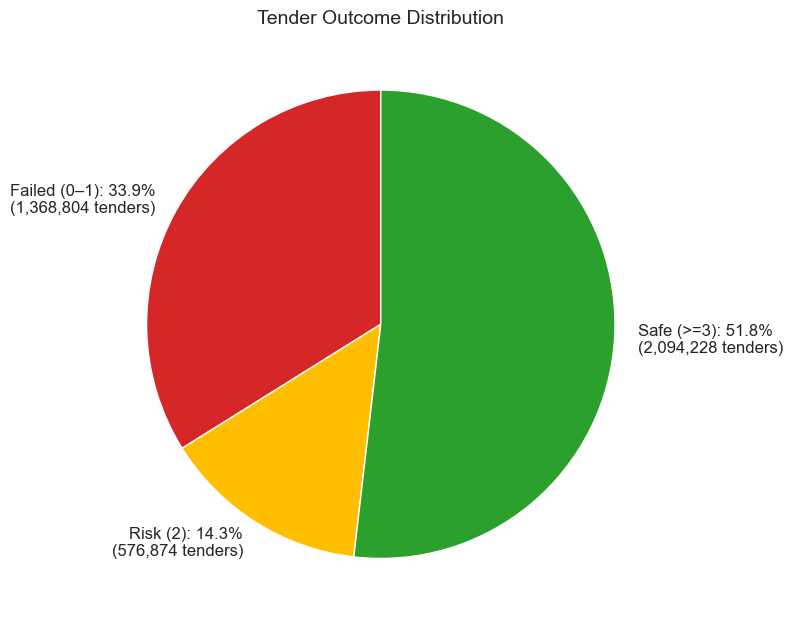

In [29]:
# ---------------------------------------------------------
# Target visualisation after revoving NUMBER_OFFERS
# ---------------------------------------------------------

# target distribution - EU
plot_target_distribution(df_clean, save=True)

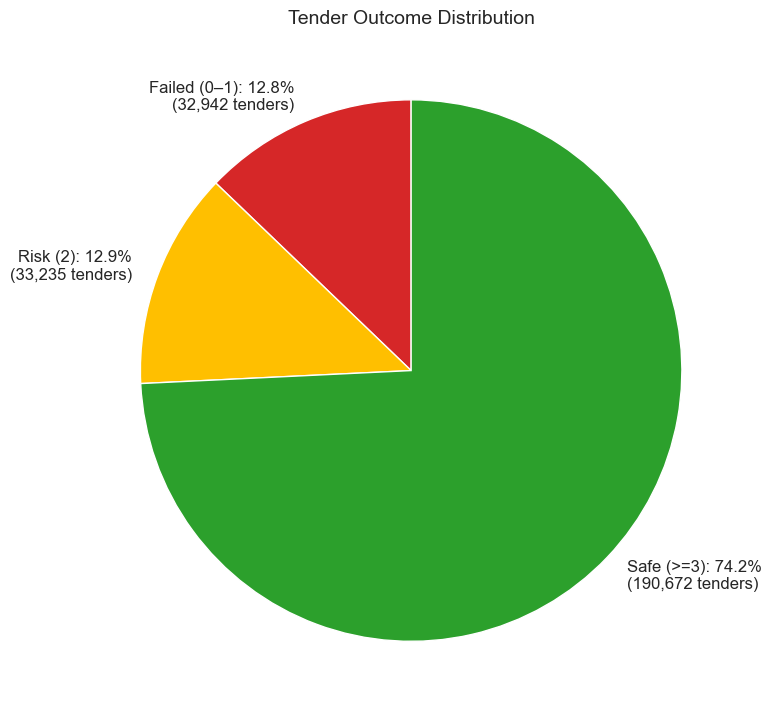

In [111]:
# target distribution - DE
plot_target_distribution(df_de_clean, save=True, path = visual_de)


In [30]:
# ---------------------------------------------------------
# IQR Outliers (1.5xIQR and 3xIQR)
# ---------------------------------------------------------

df_num = df_clean[numeric_cols].copy()

for col in numeric_cols:
    out_15 = iqr_outliers(df_num[col], factor=1.5)
    out_3 = iqr_outliers(df_num[col], factor=3)

    print(f"{col}:")
    print(f"  Outliers (1.5 IQR): {len(out_15):,}")
    print(f"  Outliers (3 IQR):   {len(out_3):,}")
    print()

VALUE_EURO:
  Outliers (1.5 IQR): 364,043
  Outliers (3 IQR):   257,593

AWARD_VALUE_EURO:
  Outliers (1.5 IQR): 351,823
  Outliers (3 IQR):   251,028

NUMBER_OFFERS:
  Outliers (1.5 IQR): 396,591
  Outliers (3 IQR):   252,986

LOTS_NUMBER:
  Outliers (1.5 IQR): 601,572
  Outliers (3 IQR):   427,724



In [31]:
# ---------------------------------------------------------
# MAD Outliers (robust for financial variables)
# ---------------------------------------------------------

for col in ["VALUE_EURO", "AWARD_VALUE_EURO"]:
    out_mad = mad_outliers(df_num[col])
    print(f"{col}: MAD outliers: {len(out_mad):,}")

VALUE_EURO: MAD outliers: 472,733
AWARD_VALUE_EURO: MAD outliers: 640,184


##### Notes: Outliers handles

1. Distribution 
- AWARD_VALUE_EURO:
The variable is extremely right‑skewed, with almost all observations concentrated near zero. The presence of extremely large values indicates potential outliers or data quality issues that should be addressed before modelling.

- LOTS_NUMBER:
LOTS_NUMBER shows a heavy right‑skew with most tenders containing only one lot. A long tail of large values suggests a small number of complex tenders with many lots, which may require special handling in outlier analysis.

- NUMBER_OFFERS:
The number of offers is strongly concentrated at very low values: most tenders receive only one or two bids, and higher counts are rare. 
During the EDA we identified extreme outliers (values above 100), which are not realistic in public procurement and typically result from data corruption or misparsed TED records. These outliers were removed to ensure a meaningful competition distribution and to prevent distortion in downstream modelling.

- VALUE_EURO:
Similar to AWARD_VALUE_EURO, VALUE_EURO is dominated by near‑zero values and contains extremely large outliers. The scale suggests possible inconsistencies or extreme cases that must be examined during data cleaning.

2. IQR and MAD

The dataset contains a very large number of outliers across key numeric variables:
- VALUE_EURO: 364k (1.5 IQR), 258k (3 IQR), 473k (MAD)
- AWARD_VALUE_EURO: 352k (1.5 IQR), 251k (3 IQR), 640k (MAD)
- NUMBER_OFFERS: 397k (1.5 IQR), 253k (3 IQR)
- LOTS_NUMBER: 602k (1.5 IQR), 428k (3 IQR)


This behaviour is expected for procurement datasets, where contract values, number of lots, and number of offers naturally exhibit heavy right‑skew and long tails.These outliers represent real economic phenomena rather than data errors.

Therefore, outliers should NOT be removed.

Recommended approach: keep all outliers and apply log‑transformation.
Log‑transforming VALUE_EURO and AWARD_VALUE_EURO:
- stabilizes variance
- reduces skewness
- preserves all information
- improves model performance
- produces distributions suitable for statistical learning
This approach is standard in economic modelling.

#### Notes: Additional recommended features for modelling  
  
Based on the structure of dates, CPV codes, competition indicators, and tender complexity, the following engineered features are recommended for modelling:
- MONTH_AWARD, QUARTER_AWARD, YEAR_AWARD
- LOTS_BIN, OFFERS_BIN, VALUE_BIN
- CPV_DIVISION, CPV_GROUP, CPV_CLASS
- HAS_MULTIPLE_LOTS
- IS_ELECTRONIC_AUCTION
- IS_JOINT_PROCUREMENT
- IS_FRAMEWORK_AGREEMENT

-------------------------

### SAVE DATASET

----------------------

In [ ]:
df_clean.to_pickle("../data/dataset.pkl")